In [10]:
import altair as alt
import matplotlib.pyplot as plt
import polars as pl

from traffic_balve.create_df import create_df

In [11]:
df = (
    create_df()
    .sort("datetime")
    .tail(100)
    .with_columns(
        delay_due_to_traffic_min=(
            pl.col("duration_in_traffic_s") - pl.col("duration_s")
        )
        / 60,
        delay_due_to_traffic_percent=100
        * (pl.col("duration_in_traffic_s") - pl.col("duration_s"))
        / pl.col("duration_s"),
    )
    .sort("datetime")
    .rolling(
        index_column="datetime",
        period="1m",
        by=["from_to"],
    )
    .agg(
        pl.col(
            "delay_due_to_traffic_percent",
            "delay_due_to_traffic_min",
            "duration_in_traffic_s",
            "duration_s",
        ).mean()
    )
    # .with_columns(
    #     date=pl.col("datetime").dt.date(),
    #     time=pl.col("datetime").dt.time(),
    # )
)[:5000]
print(df.shape)
df.head(5)

(100, 6)


from_to,datetime,delay_due_to_traffic_percent,delay_due_to_traffic_min,duration_in_traffic_s,duration_s
str,datetime[ns],f64,f64,f64,f64
"""Krankenhaus ->…",2023-12-30 05:45:02.627101,-9.195402,-0.266667,158.0,174.0
"""Krankenhaus ->…",2023-12-30 06:20:02.157805,-5.172414,-0.15,165.0,174.0
"""Krankenhaus ->…",2023-12-30 06:40:02.072030,-4.022989,-0.116667,167.0,174.0
"""Krankenhaus ->…",2023-12-30 07:35:02.160848,-4.022989,-0.116667,167.0,174.0
"""Krankenhaus ->…",2023-12-30 07:40:02.345706,-8.045977,-0.233333,160.0,174.0


In [12]:
base = (
    alt.Chart(
        df  # type:ignore
    )
    .mark_line(strokeWidth=3, point=True)
    .encode(
        x=alt.X("hoursminutes(datetime):O").title("Uhrzeit"),
        detail=alt.Detail("monthdate(datetime):O"),
        color=alt.Color("from_to:N")
        .title("Richtung")
        .scale(
            domain=[
                "Höhle -> Krankenhaus",
                "Krankenhaus -> Höhle",
                "Höhle -> Krumpaul",
                "Krumpaul -> Höhle",
                "Krankenhaus -> Krumpaul",
                "Krumpaul -> Krankenhaus",
            ],
            range=[
                "#1F77B4",
                "#AEC7E8",
                "#FF7F0E",
                "#FFBB78",
                "#2CA02C",
                "#98DF8A",
            ],
        ),
    )
    .properties(width=1500, height=250)
)


# alt.layer(
#     base.encode(
#         y=alt.Y("duration_in_traffic_s:Q").title("Reisezeit [Sekunden]"),
#     ),
#     base.mark_line(strokeWidth=2, strokeDash=[2, 2]).encode(
#         y=alt.Y("duration_s:Q").title("Reisezeit [Sekunden]"),
#     ),
# )
alt.layer(
    base.encode(
        y=alt.Y("duration_in_traffic_s:Q").title("Reisezeit [Sekunden]"),
    ),
).facet(row="from_to:N")

alt.FacetChart(...)

[Text(0.5, 0, 'Krankenhaus -> Krumpaul'),
 Text(0, 0.5, 'Krumpaul -> Krankenhaus'),
 (100.0, 300.0),
 (100.0, 300.0)]

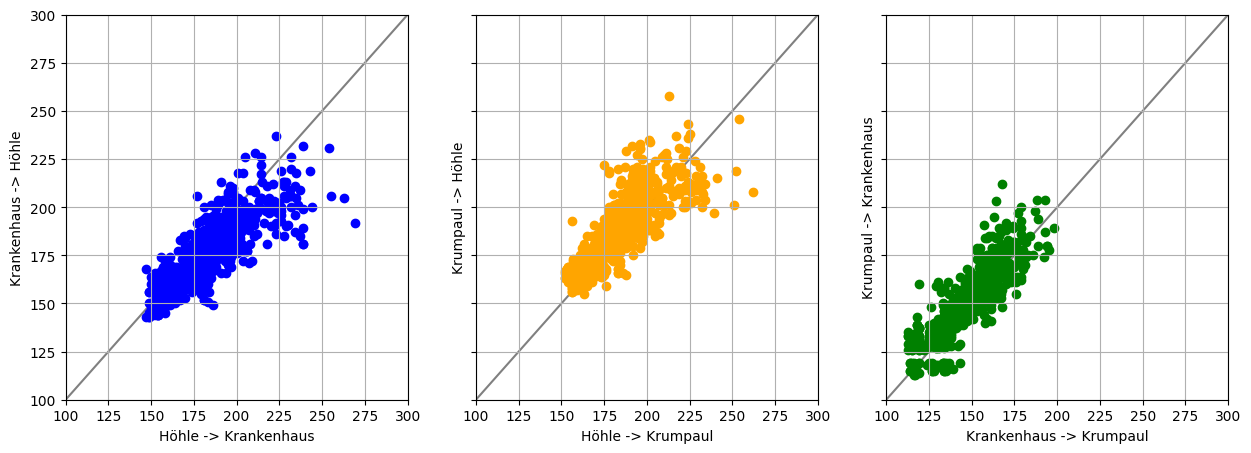

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for row in (
    create_df()
    .sort("datetime")
    .select(
        "datetime",
        "from_to",
        "duration_in_traffic_s",
    )
    .pivot(index="datetime", columns="from_to", values="duration_in_traffic_s")
    .iter_rows(named=True)
):
    axs[0].scatter(
        row["Höhle -> Krankenhaus"],
        row["Krankenhaus -> Höhle"],
        color="blue",
    )
    axs[1].scatter(
        row["Höhle -> Krumpaul"],
        row["Krumpaul -> Höhle"],
        color="orange",
    )
    axs[2].scatter(
        row["Krankenhaus -> Krumpaul"],
        row["Krumpaul -> Krankenhaus"],
        color="green",
    )
for ax in axs:
    ax.grid()
    ax.plot([100, 300], [100, 300], color="gray", zorder=-1)
axs[0].set(
    xlabel="Höhle -> Krankenhaus",
    ylabel="Krankenhaus -> Höhle",
    xlim=(100, 300),
    ylim=(100, 300),
)
axs[1].set(
    xlabel="Höhle -> Krumpaul",
    ylabel="Krumpaul -> Höhle",
    xlim=(100, 300),
    ylim=(100, 300),
)
axs[2].set(
    xlabel="Krankenhaus -> Krumpaul",
    ylabel="Krumpaul -> Krankenhaus",
    xlim=(100, 300),
    ylim=(100, 300),
)